In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import PercentFormatter

def round_to_nearest(number, nearest=100):
    return round(number / nearest) * nearest

def make_count_ytick_list(max_value):
    """Makes a list of values good for a y-axis tick mark"""
    # Let's not worry about using the max_value yet.
    return [
        0, 
        250,
        500,
        750,
        1000,
    ]

def make_count_percent_chart(df, df_index, count_col, proportion_col, count_ytick_list, color=None):
    
    df_grp = df[df_index][['Find Year', count_col, proportion_col]].groupby(['Find Year'], as_index=False).sum()
    df_grp.sort_values(by=['Find Year',], ascending=[True], inplace=True)
    
    fig, axs = plt.subplots(2, 1, sharex=True)
    fig.subplots_adjust(hspace=0)
    
    axs[0].bar(
        df_grp['Find Year'], 
        df_grp[count_col], 
        color=color,
    )  # Burnt orange color
    axs[0].set_yticks(count_ytick_list)
    axs[0].set_ylim(0, max(count_ytick_list))
    
    axs[1].bar(
        df_grp['Find Year'], 
        df_grp[proportion_col], 
        color=color,
    )  # Burnt orange color
    axs[1].set_yticks([0, 0.25, 0.5, 0.75])
    axs[1].yaxis.set_major_formatter(PercentFormatter(xmax=1))
    axs[1].set_ylim(0, 1)
    plt.show()
    

# Get the root_path for this jupyter notebook repo.
repo_path = os.path.dirname(os.path.abspath(os.getcwd()))
pc_data_path = os.path.join(
    repo_path, 'files', 'poggio-civitate',
)
object_data_path = os.path.join(
    pc_data_path, 'open-context-12827-object-records.csv',
)
df = pd.read_csv(object_data_path)
print(f'Read {len(df.index)} rows of Poggio Civitate cataloged object data.')

Read 12827 rows of Poggio Civitate cataloged object data.


In [2]:
df_year_grp = df[['Find Year']].groupby(['Find Year'], as_index=False).value_counts()
df_year_grp.sort_values(by=['Find Year',], ascending=[True], inplace=True)
df_year_grp.reset_index(drop=True, inplace=True)
df_year_grp.rename(columns={'count': 'Year Total Count'}, inplace=True)

df_year_grp.head(10)

,Find Year,Year Total Count
0,1966,317
1,1967,541
2,1968,835
3,1969,459
4,1970,496
5,1971,958
6,1972,527
7,1973,332
8,1974,44
9,1975,124


In [3]:
# Make a Dataframe counting instances of different fabrics by year
grp_cols = [
    'Find Year',
    'Main Fabric',
]
df_fabric_grp = df[grp_cols].groupby(grp_cols, as_index=False).value_counts()
df_fabric_grp.reset_index(drop=True, inplace=True)
df_fabric_grp.rename(columns={'count': 'Fabric Count'}, inplace=True)
df_fabric_grp.sort_values(by=['Find Year', 'Fabric Count', 'Main Fabric',], ascending=[True, False, True,], inplace=True)
df_fabric_grp.reset_index(drop=True, inplace=True)
df_fabric_grp = df_fabric_grp.merge(df_year_grp, on=['Find Year'], how='left')
df_fabric_grp['Fabric Proportion'] = round((df_fabric_grp['Fabric Count'] / df_fabric_grp['Year Total Count']), 3)
df_fabric_grp.head(10)

,Find Year,Main Fabric,Fabric Count,Year Total Count,Fabric Proportion
0,1966,Clay,210,317,0.662
1,1966,Terracotta,40,317,0.126
2,1966,Impasto,34,317,0.107
3,1966,Bucchero,12,317,0.038
4,1966,Bronze,8,317,0.025
5,1966,Coarse Ware,3,317,0.009
6,1966,Stone,3,317,0.009
7,1966,Plaster,2,317,0.006
8,1966,Antler,1,317,0.003
9,1966,Glass,1,317,0.003


In [4]:
# Save the resulting summary of fabric counts by year
fabric_yearly_summary_path = os.path.join(
    pc_data_path, 'poggio-civitate-cataloged-object-fabric-yearly-summary.csv',
)
df_fabric_grp.to_csv(fabric_yearly_summary_path, index=False)
print(f'Saved {len(df_fabric_grp.index)} rows of cataloged object fabric counts by year to: {fabric_yearly_summary_path}')

Saved 897 rows of cataloged object fabric counts by year to: /home/ekansa/github/open-context-jupyter/files/poggio-civitate/poggio-civitate-cataloged-object-fabric-yearly-summary.csv


In [5]:
# Make a Dataframe counting instances of different object types by year
grp_cols = [
    'Find Year',
    'Main Object Type',
]
df_type_grp = df[grp_cols].groupby(grp_cols, as_index=False).value_counts()
df_type_grp.reset_index(drop=True, inplace=True)
df_type_grp.rename(columns={'count': 'Type Count'}, inplace=True)
df_type_grp.sort_values(by=['Find Year', 'Type Count', 'Main Object Type',], ascending=[True, False, True,], inplace=True)
df_type_grp.reset_index(drop=True, inplace=True)
df_type_grp = df_type_grp.merge(df_year_grp, on=['Find Year'], how='left')
df_type_grp['Type Proportion'] = round((df_type_grp['Type Count'] / df_type_grp['Year Total Count']), 3)
df_type_grp.head(10)

,Find Year,Main Object Type,Type Count,Year Total Count,Type Proportion
0,1966,Architectural,238,317,0.751
1,1966,Vessel,33,317,0.104
2,1966,Textile Related,26,317,0.082
3,1966,Tool / Weapon,5,317,0.016
4,1966,"Costume, Accessories",4,317,0.013
5,1966,Pyrotech Related,3,317,0.009
6,1966,Fastener,2,317,0.006
7,1966,Shaped Object,2,317,0.006
8,1966,Figurine / Statuette,1,317,0.003
9,1966,Ornament,1,317,0.003


In [6]:
# Save the resulting summary of object type counts by year
type_yearly_summary_path = os.path.join(
    pc_data_path, 'poggio-civitate-cataloged-object-type-yearly-summary.csv',
)
df_type_grp.to_csv(type_yearly_summary_path, index=False)
print(f'Saved {len(df_type_grp.index)} rows of cataloged object fabric counts by year to: {type_yearly_summary_path}')

Saved 682 rows of cataloged object fabric counts by year to: /home/ekansa/github/open-context-jupyter/files/poggio-civitate/poggio-civitate-cataloged-object-type-yearly-summary.csv


In [7]:
# Make a ytick list for the counts based on the maximum count for all types. 
# This helps normalize views of the absolute number of counts for all types.
count_ytick_list = make_count_ytick_list(df_year_grp['Year Total Count'].max()) 


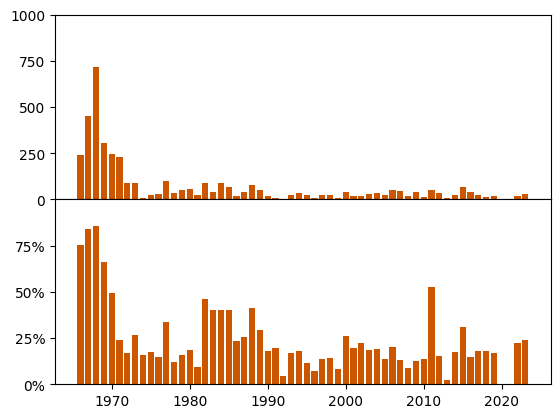

In [8]:
# Make a chart of architectural related object types by year
arch_type_fig_index = df_type_grp['Main Object Type'].isin(['Architectural',])
make_count_percent_chart(
    df=df_type_grp, 
    df_index=arch_type_fig_index, 
    count_col='Type Count', 
    proportion_col='Type Proportion', 
    count_ytick_list=count_ytick_list, 
    color='#CC5500',
)

In [ ]:
# Make a chart of textile related object types by year
arch_type_fig_index = df_type_grp['Main Object Type'].isin(['Textile Related',])
make_count_percent_chart(
    df=df_type_grp, 
    df_index=arch_type_fig_index, 
    count_col='Type Count', 
    proportion_col='Type Proportion', 
    count_ytick_list=count_ytick_list, 
    color='#1d0033',
)

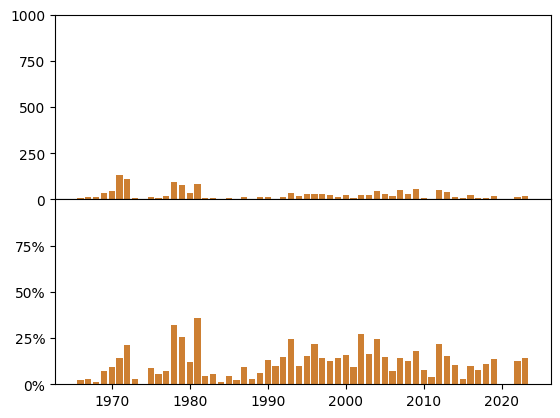

In [14]:
# Make a chart of yearly frequency of metal materials (fabrics)
metal_fabrics = ['Bronze', 'Iron']
metal_fabs_fig_index = df_fabric_grp['Main Fabric'].isin(metal_fabrics)

make_count_percent_chart(
    df=df_fabric_grp, 
    df_index=metal_fabs_fig_index, 
    count_col='Fabric Count', 
    proportion_col='Fabric Proportion', 
    count_ytick_list=count_ytick_list, 
    color='#CD7F32',
)


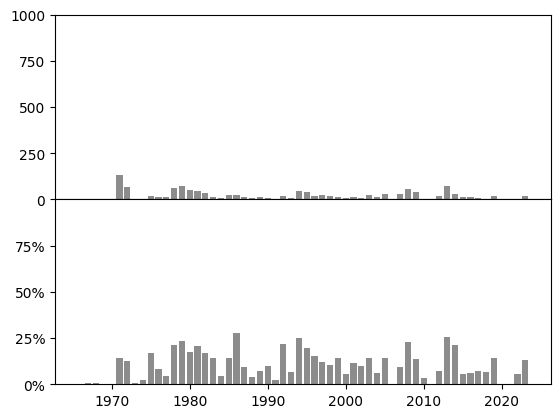

In [15]:
# Make a chart of yearly frequency of animal related materials (fabrics)
animal_fabrics = ['Bone', 'Antler', 'Ivory',]
animal_fabs_fig_index = df_fabric_grp['Main Fabric'].isin(animal_fabrics)

make_count_percent_chart(
    df=df_fabric_grp, 
    df_index=animal_fabs_fig_index, 
    count_col='Fabric Count', 
    proportion_col='Fabric Proportion', 
    count_ytick_list=count_ytick_list, 
    color='#8c8c8c',
)